In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install -q gdown

In [3]:
!gdown --id 14K-mX-Aqqk8cNdTmZHEmMVf7y4wtuSxJ --output animals10.zip

/usr/local/lib/python3.11/dist-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=14K-mX-Aqqk8cNdTmZHEmMVf7y4wtuSxJ
From (redirected): https://drive.google.com/uc?id=14K-mX-Aqqk8cNdTmZHEmMVf7y4wtuSxJ&confirm=t&uuid=9080eb1b-7436-4c18-8ebc-2066810b6c6b
To: /content/animals10.zip
100% 614M/614M [00:20<00:00, 29.5MB/s]


In [4]:
!unzip -q animals10.zip -d ./animals10

In [ ]:
# import shutil
# import os

# root_dir = '/content/animals10/'

# for item in os.listdir(root_dir):
#     item_path = os.path.join(root_dir, item)

#     try:
#         if os.path.isfile(item_path) or os.path.islink(item_path):
#             os.unlink(item_path)
#         elif os.path.isdir(item_path):
#             shutil.rmtree(item_path)
#     except Exception as e:
#         print(f"Помилка при видаленні {item_path}: {e}")


In [5]:
data_dir = './animals10/raw-img'

translate = {
    "cane": "dog",
    "cavallo": "horse",
    "elefante": "elephant",
    "farfalla": "butterfly",
    "gallina": "chicken",
    "gatto": "cat",
    "mucca": "cow",
    "pecora": "sheep",
    "ragno": "spider",
    "scoiattolo": "squirrel"
}

In [6]:
import os

for italian, english in translate.items():
    src = os.path.join(data_dir, italian)
    dst = os.path.join(data_dir, english)

    if os.path.exists(src):
        os.rename(src, dst)

In [7]:
from torchvision import datasets, transforms

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])


data = datasets.ImageFolder(data_dir, transform=transform)

In [8]:
import numpy as np
from torch.utils.data import Subset
from sklearn.model_selection import train_test_split

labels = np.array(data.targets)

train_val_idx, test_idx = train_test_split(
    np.arange(len(data)), test_size=0.2, random_state=42, shuffle=True, stratify=labels
)

train_idx, val_idx = train_test_split(
    train_val_idx, test_size=0.25, random_state=42, shuffle=True, stratify=labels[train_val_idx]
)

train_data = Subset(data, train_idx)
val_data = Subset(data, val_idx)
test_data = Subset(data, test_idx)

In [9]:
print(f"Train size: {len(train_data)}")
print(f"Validation size: {len(val_data)}")
print(f"Test size: {len(test_data)}")

Train size: 15707
Validation size: 5236
Test size: 5236


In [10]:
from torch.utils.data import DataLoader

batch_size = 32
num_workers = 2

train_loader = DataLoader(
    train_data, batch_size=batch_size, shuffle=True, num_workers=num_workers
)

val_loader = DataLoader(
    val_data, batch_size=batch_size, shuffle=False, num_workers=num_workers
)

test_loader = DataLoader(
    test_data, batch_size=batch_size, shuffle=False, num_workers=num_workers
)

In [11]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor()
])

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

In [12]:
train_loader.dataset.transform = train_transform
val_loader.dataset.transform = val_test_transform
test_loader.dataset.transform = val_test_transform

In [13]:
import torch
import torch.nn as nn

class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()

        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(2, 2)

        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(2, 2)

        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.relu3 = nn.ReLU()

        self.conv4 = nn.Conv2d(128, 256, 3, padding=1)
        self.bn4 = nn.BatchNorm2d(256)
        self.relu4 = nn.ReLU()
        self.pool3 = nn.MaxPool2d(2, 2)

        self.conv5 = nn.Conv2d(256, 512, 3, padding=1)
        self.bn5 = nn.BatchNorm2d(512)
        self.relu5 = nn.ReLU()
        self.pool4 = nn.MaxPool2d(2, 2)

        self.adaptive_pool = nn.AdaptiveAvgPool2d((1, 1))

        self.fc1 = nn.Linear(512, 256)
        self.relu_fc1 = nn.ReLU()
        self.dropout1 = nn.Dropout(0.2)

        self.fc2 = nn.Linear(256, 128)
        self.relu_fc2 = nn.ReLU()
        self.dropout2 = nn.Dropout(0.2)

        self.fc3 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu1(x)
        x = self.pool1(x)

        x = self.conv2(x)
        x = self.bn2(x)
        x = self.relu2(x)
        x = self.pool2(x)

        x = self.conv3(x)
        x = self.bn3(x)
        x = self.relu3(x)

        x = self.conv4(x)
        x = self.bn4(x)
        x = self.relu4(x)
        x = self.pool3(x)

        x = self.conv5(x)
        x = self.bn5(x)
        x = self.relu5(x)
        x = self.pool4(x)

        x = self.adaptive_pool(x)
        x = torch.flatten(x, 1)

        x = self.fc1(x)
        x = self.relu_fc1(x)
        x = self.dropout1(x)

        x = self.fc2(x)
        x = self.relu_fc2(x)
        x = self.dropout2(x)

        x = self.fc3(x)

        return x

In [14]:
import torch.optim as optim

model = CNN()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(), lr=0.001)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3, verbose=True
)

device

/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


device(type='cuda')

In [15]:
import torch
from sklearn.metrics import f1_score, accuracy_score
import matplotlib.pyplot as plt

In [16]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    all_preds = []
    all_labels = []

    for inputs, labels in loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)

        preds = outputs.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)
    epoch_f1 = f1_score(all_labels, all_preds, average='weighted')

    return epoch_loss, epoch_acc, epoch_f1

In [17]:
def validate_one_epoch(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * inputs.size(0)

            preds = outputs.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)
    epoch_f1 = f1_score(all_labels, all_preds, average='weighted')

    return epoch_loss, epoch_acc, epoch_f1

In [18]:
num_epochs = 20

train_losses, val_losses = [], []
train_accs, val_accs = [], []
train_f1s, val_f1s = [], []

In [ ]:
for epoch in range(num_epochs):
    train_loss, train_acc, train_f1 = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc, val_f1 = validate_one_epoch(model, val_loader, criterion, device)

    scheduler.step(val_loss)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)
    train_f1s.append(train_f1)
    val_f1s.append(val_f1)

    print(f"Epoch [{epoch+1}/{num_epochs}]")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Train F1: {train_f1:.4f}")
    print(f"Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.4f} | Val   F1: {val_f1:.4f}")
    print('-' * 40)

Epoch [1/20]
Train Loss: 1.8856 | Train Acc: 0.3214 | Train F1: 0.2821
Val   Loss: 1.8673 | Val   Acc: 0.3449 | Val   F1: 0.2915
----------------------------------------
Epoch [2/20]
Train Loss: 1.6243 | Train Acc: 0.4141 | Train F1: 0.3863
Val   Loss: 1.5266 | Val   Acc: 0.4509 | Val   F1: 0.4309
----------------------------------------
Epoch [3/20]
Train Loss: 1.4687 | Train Acc: 0.4786 | Train F1: 0.4564
Val   Loss: 1.7607 | Val   Acc: 0.3957 | Val   F1: 0.4114
----------------------------------------
Epoch [4/20]
Train Loss: 1.3425 | Train Acc: 0.5211 | Train F1: 0.5041
Val   Loss: 1.2967 | Val   Acc: 0.5386 | Val   F1: 0.5186
----------------------------------------
Epoch [5/20]
Train Loss: 1.2582 | Train Acc: 0.5585 | Train F1: 0.5432
Val   Loss: 1.3129 | Val   Acc: 0.5327 | Val   F1: 0.5207
----------------------------------------
Epoch [6/20]
Train Loss: 1.1799 | Train Acc: 0.5918 | Train F1: 0.5809
Val   Loss: 2.4019 | Val   Acc: 0.3753 | Val   F1: 0.3123
---------------------

In [ ]:
torch.save(model.state_dict(), 'model2.pth')

In [19]:
epochs = range(1, num_epochs + 1)

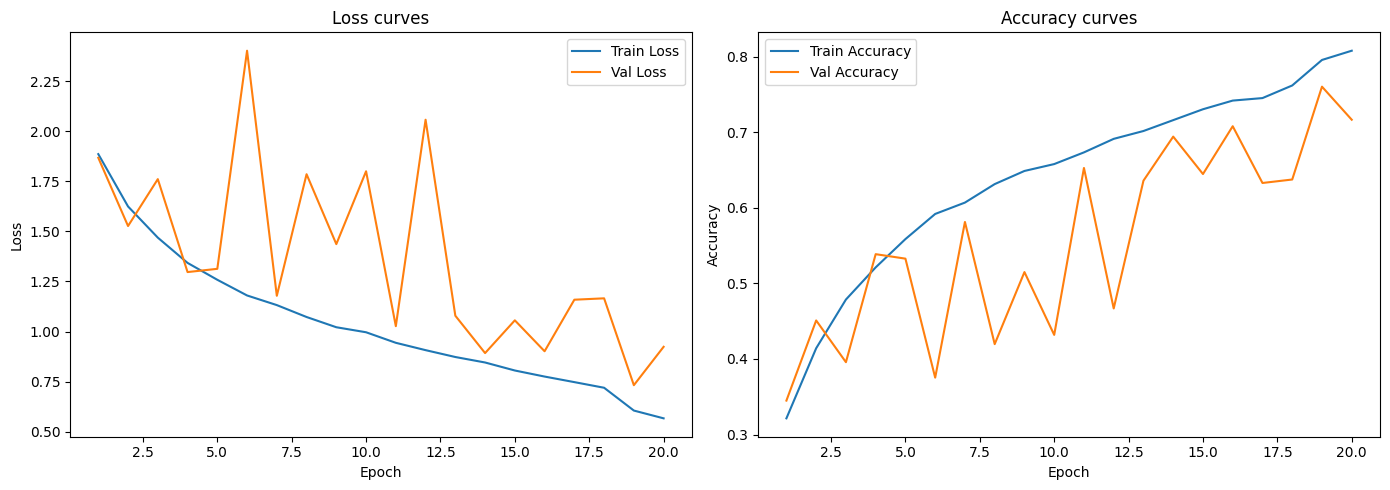

In [ ]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs, train_losses, label='Train Loss')
plt.plot(epochs, val_losses, label='Val Loss')
plt.title('Loss curves')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, train_accs, label='Train Accuracy')
plt.plot(epochs, val_accs, label='Val Accuracy')
plt.title('Accuracy curves')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

In [20]:
model.load_state_dict(torch.load('/content/model2.pth'))
model.eval()

CNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu1): ReLU()
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu2): ReLU()
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu3): ReLU()
  (conv4): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn4): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu4): ReLU()
  (pool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=Fals

In [21]:
model.to(device)

CNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu1): ReLU()
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu2): ReLU()
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu3): ReLU()
  (conv4): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn4): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu4): ReLU()
  (pool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=Fals

In [22]:
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

def evaluate_on_test(model, loader, device):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs)
            preds = outputs.argmax(dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='weighted')

    print(f"Test Accuracy: {acc:.4f}")
    print(f"Test F1-score: {f1:.4f}")
    print("\nClassification Report:")
    print(classification_report(all_labels, all_preds))

    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title('Confusion Matrix на тестовому наборі')
    plt.xlabel('Прогнозований клас')
    plt.ylabel('Справжній клас')
    plt.show()

Test Accuracy: 0.7330
Test F1-score: 0.7181

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.77      0.83       422
           1       0.83      0.34      0.48       334
           2       0.81      0.87      0.84       620
           3       0.61      0.54      0.57       373
           4       0.65      0.83      0.73       973
           5       0.95      0.54      0.68       289
           6       0.62      0.81      0.71       525
           7       0.94      0.32      0.48       364
           8       0.74      0.97      0.84       964
           9       0.79      0.58      0.67       372

    accuracy                           0.73      5236
   macro avg       0.78      0.66      0.68      5236
weighted avg       0.76      0.73      0.72      5236



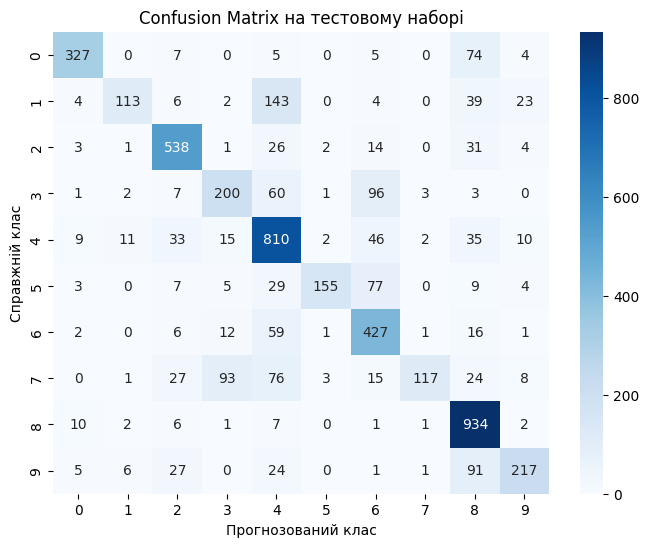

In [23]:
evaluate_on_test(model, test_loader, device)

In [ ]:
for epoch in range(1):
    train_loss, train_acc, train_f1 = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc, val_f1 = validate_one_epoch(model, val_loader, criterion, device)

    scheduler.step(val_loss)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)
    train_f1s.append(train_f1)
    val_f1s.append(val_f1)

    print(f"Epoch [{epoch+1}/{num_epochs}]")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Train F1: {train_f1:.4f}")
    print(f"Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.4f} | Val   F1: {val_f1:.4f}")
    print('-' * 40)

Epoch [1/20]
Train Loss: 0.5512 | Train Acc: 0.8183 | Train F1: 0.8174
Val   Loss: 0.7595 | Val   Acc: 0.7603 | Val   F1: 0.7610
----------------------------------------


In [ ]:
for epoch in range(5):
    train_loss, train_acc, train_f1 = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc, val_f1 = validate_one_epoch(model, val_loader, criterion, device)

    scheduler.step(val_loss)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)
    train_f1s.append(train_f1)
    val_f1s.append(val_f1)

    print(f"Epoch [{epoch+1}/{num_epochs}]")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Train F1: {train_f1:.4f}")
    print(f"Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.4f} | Val   F1: {val_f1:.4f}")
    print('-' * 40)

    torch.save(model.state_dict(), f'model2_2{epoch + 2}.pth')

Epoch [1/20]
Train Loss: 0.5264 | Train Acc: 0.8232 | Train F1: 0.8223
Val   Loss: 0.7361 | Val   Acc: 0.7674 | Val   F1: 0.7626
----------------------------------------
Epoch [2/20]
Train Loss: 0.5047 | Train Acc: 0.8303 | Train F1: 0.8294
Val   Loss: 0.7782 | Val   Acc: 0.7624 | Val   F1: 0.7596
----------------------------------------
Epoch [3/20]
Train Loss: 0.4263 | Train Acc: 0.8563 | Train F1: 0.8557
Val   Loss: 0.6233 | Val   Acc: 0.8044 | Val   F1: 0.8042
----------------------------------------
Epoch [4/20]
Train Loss: 0.4047 | Train Acc: 0.8653 | Train F1: 0.8649
Val   Loss: 0.6281 | Val   Acc: 0.8050 | Val   F1: 0.8046
----------------------------------------
Epoch [5/20]
Train Loss: 0.3955 | Train Acc: 0.8652 | Train F1: 0.8649
Val   Loss: 0.6525 | Val   Acc: 0.7947 | Val   F1: 0.7939
----------------------------------------


In [ ]:
epochs = range(1, 27)

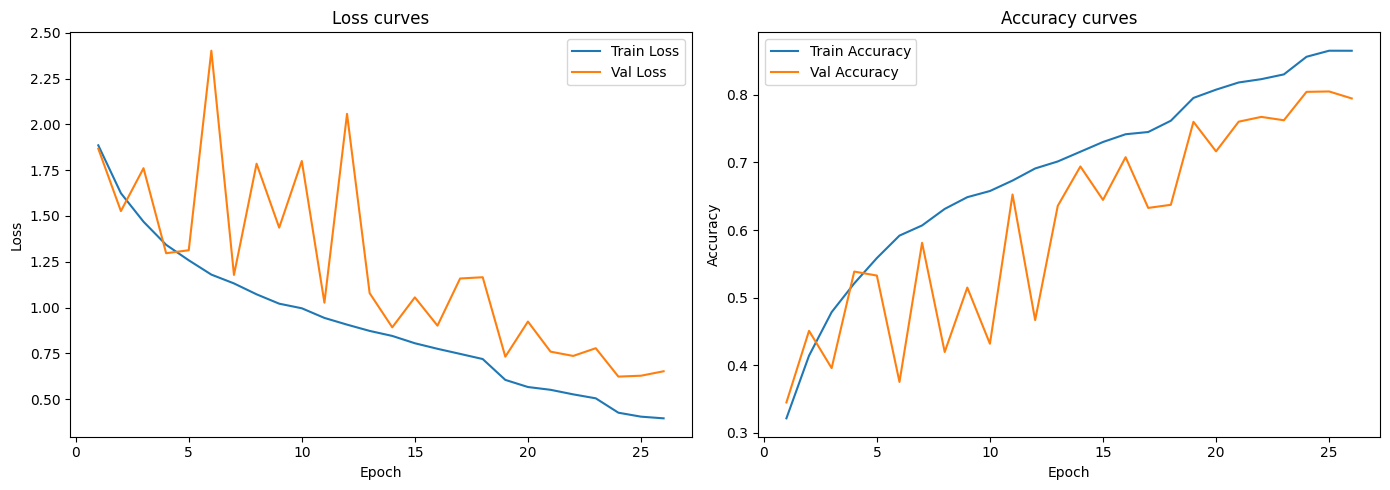

In [ ]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs, train_losses, label='Train Loss')
plt.plot(epochs, val_losses, label='Val Loss')
plt.title('Loss curves')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, train_accs, label='Train Accuracy')
plt.plot(epochs, val_accs, label='Val Accuracy')
plt.title('Accuracy curves')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

Test Accuracy: 0.7769
Test F1-score: 0.7723

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.89      0.82       422
           1       0.79      0.51      0.62       334
           2       0.77      0.88      0.82       620
           3       0.65      0.69      0.67       373
           4       0.79      0.77      0.78       973
           5       0.86      0.72      0.78       289
           6       0.68      0.81      0.74       525
           7       0.84      0.59      0.69       364
           8       0.84      0.93      0.88       964
           9       0.77      0.60      0.68       372

    accuracy                           0.78      5236
   macro avg       0.78      0.74      0.75      5236
weighted avg       0.78      0.78      0.77      5236



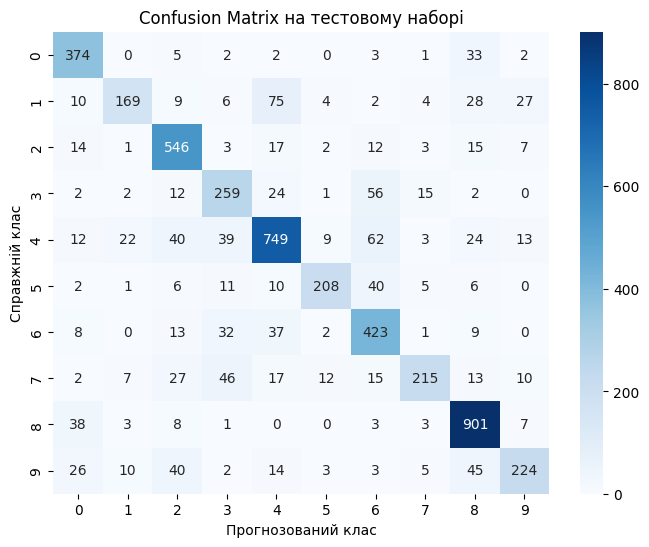

----------------------------------------




Test Accuracy: 0.7695
Test F1-score: 0.7677

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.85      0.83       422
           1       0.85      0.46      0.60       334
           2       0.89      0.82      0.85       620
           3       0.70      0.54      0.61       373
           4       0.68      0.85      0.76       973
           5       0.70      0.82      0.76       289
           6       0.58      0.87      0.70       525
           7       0.91      0.56      0.69       364
           8       0.92      0.86      0.89       964
           9       0.85      0.68      0.76       372

    accuracy                           0.77      5236
   macro avg       0.79      0.73      0.74      5236
weighted avg       0.79      0.77      0.77      5236



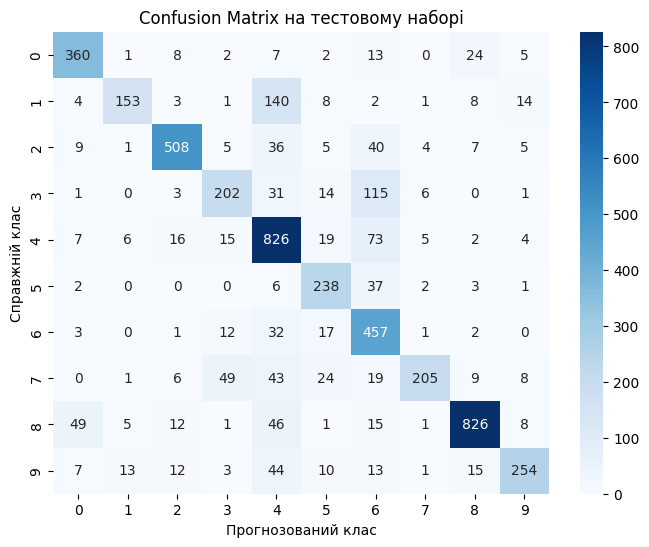

----------------------------------------




Test Accuracy: 0.8109
Test F1-score: 0.8108

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.90      0.85       422
           1       0.68      0.69      0.69       334
           2       0.85      0.89      0.87       620
           3       0.72      0.71      0.71       373
           4       0.79      0.80      0.79       973
           5       0.78      0.87      0.82       289
           6       0.74      0.83      0.78       525
           7       0.84      0.68      0.75       364
           8       0.94      0.87      0.90       964
           9       0.82      0.73      0.77       372

    accuracy                           0.81      5236
   macro avg       0.80      0.80      0.79      5236
weighted avg       0.81      0.81      0.81      5236



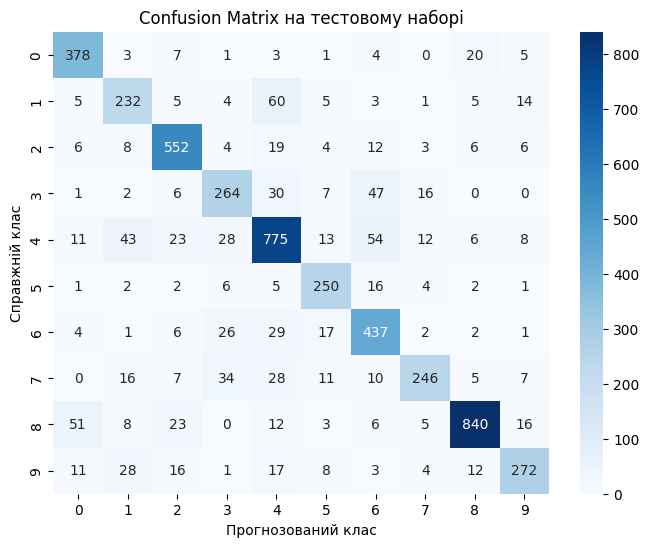

----------------------------------------




Test Accuracy: 0.8178
Test F1-score: 0.8179

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.84      0.88       422
           1       0.71      0.67      0.69       334
           2       0.88      0.89      0.88       620
           3       0.74      0.68      0.71       373
           4       0.73      0.85      0.79       973
           5       0.86      0.84      0.85       289
           6       0.80      0.77      0.78       525
           7       0.82      0.68      0.75       364
           8       0.93      0.90      0.91       964
           9       0.75      0.84      0.79       372

    accuracy                           0.82      5236
   macro avg       0.81      0.80      0.80      5236
weighted avg       0.82      0.82      0.82      5236



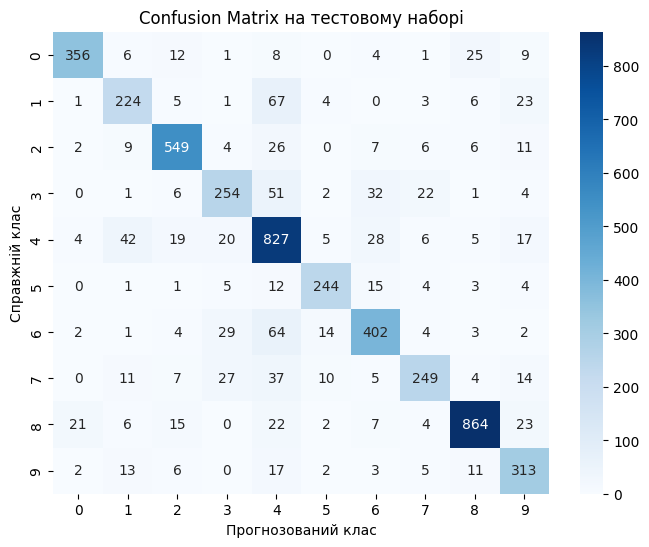

----------------------------------------




Test Accuracy: 0.8077
Test F1-score: 0.8065

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.91      0.87       422
           1       0.68      0.70      0.69       334
           2       0.77      0.92      0.84       620
           3       0.74      0.69      0.71       373
           4       0.87      0.71      0.78       973
           5       0.72      0.89      0.79       289
           6       0.75      0.82      0.78       525
           7       0.80      0.70      0.75       364
           8       0.92      0.91      0.92       964
           9       0.81      0.74      0.77       372

    accuracy                           0.81      5236
   macro avg       0.79      0.80      0.79      5236
weighted avg       0.81      0.81      0.81      5236



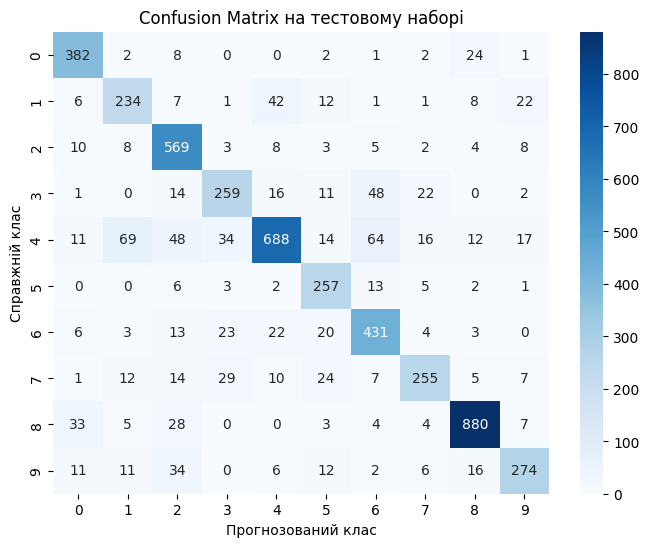

----------------------------------------






In [24]:
for epoch in range(5):
    model.load_state_dict(torch.load(f'/content/model2_2{epoch + 2}.pth'))
    model.eval()
    model.to(device)
    evaluate_on_test(model, test_loader, device)
    print('-' * 40)
    print('\n' * 3)

на 25 епосі модель найкраща. Всього було 26 епох.